# Run Model on Single Image with Augmentation

This notebook loads the fine-tuned defect detection model and runs inference on a single training image.

**Workflow**:
1. Load original image by name
2. Apply lithography augmentation (SEM + blur)
3. Display augmented image
4. Run model prediction on augmented image
5. Display predictions vs ground truth


In [42]:
# Imports and configuration
import os
import json
from collections import defaultdict
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy import ndimage
from scipy.signal import fftconvolve
from scipy.special import j1

# Device configuration
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required but was not found.")

DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

# Paths
DATA_ROOT = "."
TRAIN_JSON = os.path.join(DATA_ROOT, "train", "_annotations.coco.json")
MODEL_PATH = os.path.join("models", "defect_detector_stage2_litho_finetuned.pth")

# Inference settings
CONFIDENCE_THRESHOLD = 0.5

print("Configuration loaded!")

Using device: cuda
Configuration loaded!


In [43]:
# Load training annotations
with open(TRAIN_JSON, "r") as f:
    train_coco = json.load(f)

train_images = train_coco["images"]
train_annotations = train_coco["annotations"]

# Create mappings
image_id_to_anns = defaultdict(list)
for ann in train_annotations:
    image_id_to_anns[ann["image_id"]].append(ann)

image_id_to_info = {img["id"]: img for img in train_images}
filename_to_info = {img["file_name"]: img for img in train_images}

print(f"Loaded {len(train_images)} training images with annotations")

Loaded 1053 training images with annotations


In [44]:
# Lithography augmentation functions

def convert_to_sem_style(img):
    """Apply SEM-style conversion with blur, noise, and grain."""
    img_gray = img.convert("L")
    img_array = np.array(img_gray).astype(float) / 255.0

    # Color remap: 0 -> 124/255, 1 -> 57/255
    img_remapped = img_array * (-67 / 255.0) + (124 / 255.0)

    # Gaussian blur (sigma=0.05)
    img_blur = ndimage.gaussian_filter(img_remapped, sigma=0.05)

    # Noise
    noise = np.random.normal(0, 0.015, img_blur.shape)
    img_noisy = img_blur + noise
    img_noisy = np.clip(img_noisy, 0.0, 1.0)

    # Fine grain texture
    grain_size = 2
    grain = np.random.normal(0, 0.01, (img_noisy.shape[0] // grain_size, img_noisy.shape[1] // grain_size))
    grain_upscaled = ndimage.zoom(grain, grain_size, order=1)
    if grain_upscaled.shape != img_noisy.shape:
        grain_upscaled = grain_upscaled[: img_noisy.shape[0], : img_noisy.shape[1]]
    img_grain = img_noisy + grain_upscaled
    img_grain = np.clip(img_grain, 0.0, 1.0)

    # Vignetting
    rows, cols = img_grain.shape
    y, x = np.ogrid[:rows, :cols]
    center_y, center_x = rows / 2, cols / 2
    max_dist = np.sqrt(center_y ** 2 + center_x ** 2)
    dist_from_center = np.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
    vignette = 1 - 0.06 * (dist_from_center / max_dist) ** 2
    img_sem = img_grain * vignette

    img_sem = np.clip(img_sem, 0.0, 1.0)
    img_sem = (img_sem * 255).astype(np.uint8)
    return Image.fromarray(img_sem)


def simulate_lithography(img, wavelength=193, na=1.2, defocus=0, dose=1.0):
    """Optical lithography simulation with Airy disk PSF (physical blur)."""
    img_gray = img.convert("L")
    mask = np.array(img_gray).astype(float) / 255.0
    mask_pattern = mask

    # Optical PSF
    resolution_limit = wavelength / (2 * na)
    pixel_scale = 10  # nm per pixel
    psf_radius_pixels = int(resolution_limit / pixel_scale)
    psf_radius_pixels = max(5, min(psf_radius_pixels, 50))

    y, x = np.ogrid[-psf_radius_pixels : psf_radius_pixels + 1, -psf_radius_pixels : psf_radius_pixels + 1]
    r = np.sqrt(x ** 2 + y ** 2)

    v = 2 * np.pi * na * r * pixel_scale / wavelength
    v[v == 0] = 1e-10
    airy = (2 * j1(v) / v) ** 2
    airy = airy / airy.sum()

    if defocus != 0:
        defocus_phase = np.pi * na ** 2 * (r * pixel_scale) ** 2 * defocus / wavelength ** 2
        defocus_kernel = np.cos(defocus_phase)
        airy = airy * (1 + 0.5 * defocus_kernel)
        airy = airy / airy.sum()

    # FFT convolution
    aerial_image = fftconvolve(mask_pattern, airy, mode="same")
    aerial_image = np.clip(aerial_image, 0.0, 1.0)

    # Resist simulation
    exposure = aerial_image * dose
    resist_contrast = 5.0
    threshold = 0.5
    developed_resist = 1 / (1 + np.exp(-resist_contrast * (exposure - threshold)))

    # Process variations
    ler_noise = np.random.normal(0, 0.02, developed_resist.shape)
    developed_resist = np.clip(developed_resist + ler_noise, 0, 1)

    defect_probability = 0.001
    defect_mask = np.random.random(developed_resist.shape) < defect_probability
    if defect_mask.any():
        developed_resist[defect_mask] = np.random.uniform(0.3, 0.7, np.sum(defect_mask))

    final_pattern = (developed_resist * 255).astype(np.uint8)
    return Image.fromarray(final_pattern)


def apply_lithography_augmentation(img):
    """Apply full lithography pipeline: SEM + optical simulation."""
    sem_img = convert_to_sem_style(img)
    wafer_img = simulate_lithography(sem_img, wavelength=193, na=1.2, defocus=0, dose=1.0)
    wafer_img_rgb = wafer_img.convert("RGB")
    return wafer_img_rgb


print("Lithography augmentation functions loaded!")

Lithography augmentation functions loaded!


In [45]:
# Load the fine-tuned model
def create_defect_detector(one_class=True):
    if one_class:
        num_classes = 2  # background + defect
    else:
        num_classes = 8  # background + 7 defect categories

    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = create_defect_detector(one_class=True)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("✓ Fine-tuned model loaded successfully!")

✓ Fine-tuned model loaded successfully!


In [46]:
# ========================================
# SET YOUR IMAGE NAME HERE
# ========================================
IMAGE_NAME = "00001504_jpg.rf.3c85b32cd1c2be3b4e9163ebb07b206a.jpg" 

# You can change this to any training image filename
# To see available images, check the train/ folder or train annotations

print(f"Image name set to: {IMAGE_NAME}")

Image name set to: 00001504_jpg.rf.3c85b32cd1c2be3b4e9163ebb07b206a.jpg


In [47]:
# Load image and ground truth annotations
print(f"Loading image: {IMAGE_NAME}")

# Check if image exists in training set
if IMAGE_NAME not in filename_to_info:
    raise ValueError(f"Image '{IMAGE_NAME}' not found in training set")

img_info = filename_to_info[IMAGE_NAME]
image_id = img_info["id"]

# Load original image
img_path = os.path.join("train", IMAGE_NAME)
if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image file not found: {img_path}")

original_img = Image.open(img_path).convert("RGB")
original_img_np = np.array(original_img)
print(f"✓ Original image loaded: {original_img.size[0]}x{original_img.size[1]} pixels")

# Get ground truth annotations
gt_anns = image_id_to_anns[image_id]
gt_boxes = []
for ann in gt_anns:
    x, y, w, h = ann["bbox"]
    gt_boxes.append([x, y, x + w, y + h])

num_gt = len(gt_boxes)
print(f"✓ Ground truth: {num_gt} defect(s)")

# Apply lithography augmentation
print("Applying lithography augmentation (SEM + blur)...")
augmented_img = apply_lithography_augmentation(original_img)
augmented_img_np = np.array(augmented_img)
print("✓ Augmentation complete!")

Loading image: 00001504_jpg.rf.3c85b32cd1c2be3b4e9163ebb07b206a.jpg
✓ Original image loaded: 640x640 pixels
✓ Ground truth: 9 defect(s)
Applying lithography augmentation (SEM + blur)...
✓ Augmentation complete!


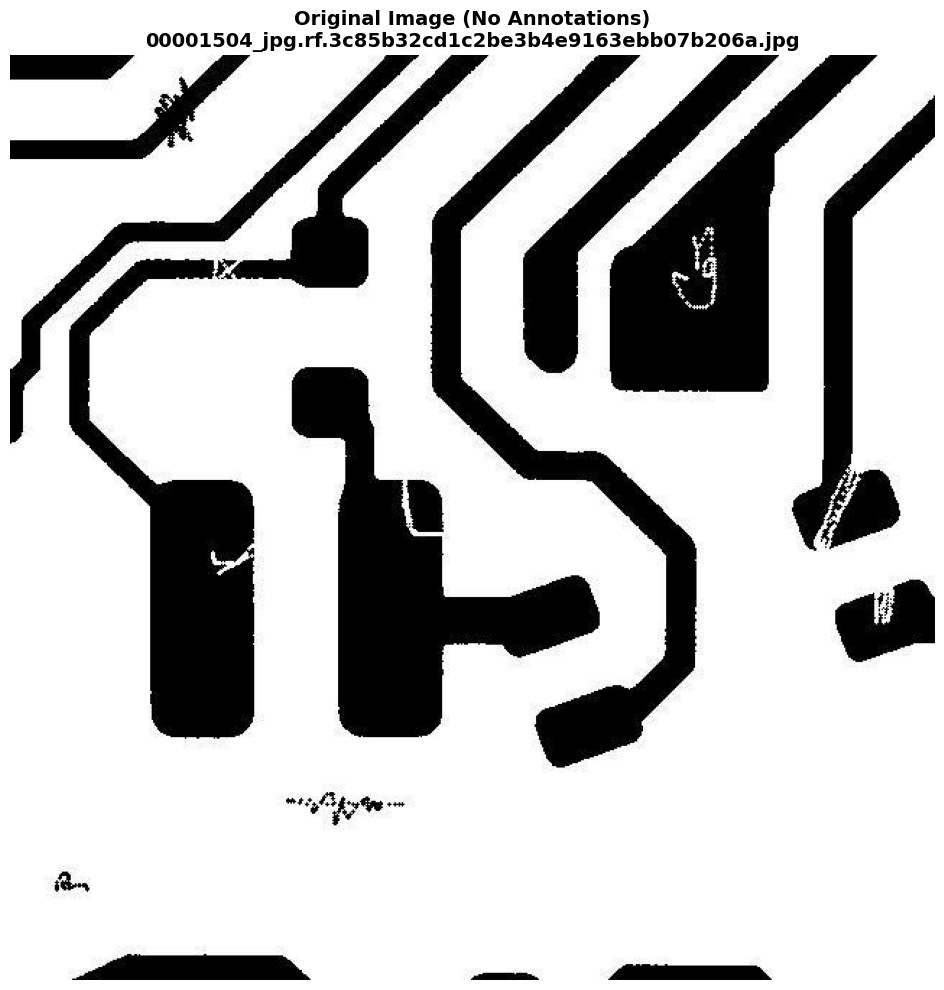

✓ Original image displayed (without bounding boxes)


In [48]:
# Display original image (no bounding boxes)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.imshow(original_img_np)
ax.set_title(f"Original Image (No Annotations)\n{IMAGE_NAME}", fontsize=14, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.show()

print("✓ Original image displayed (without bounding boxes)")

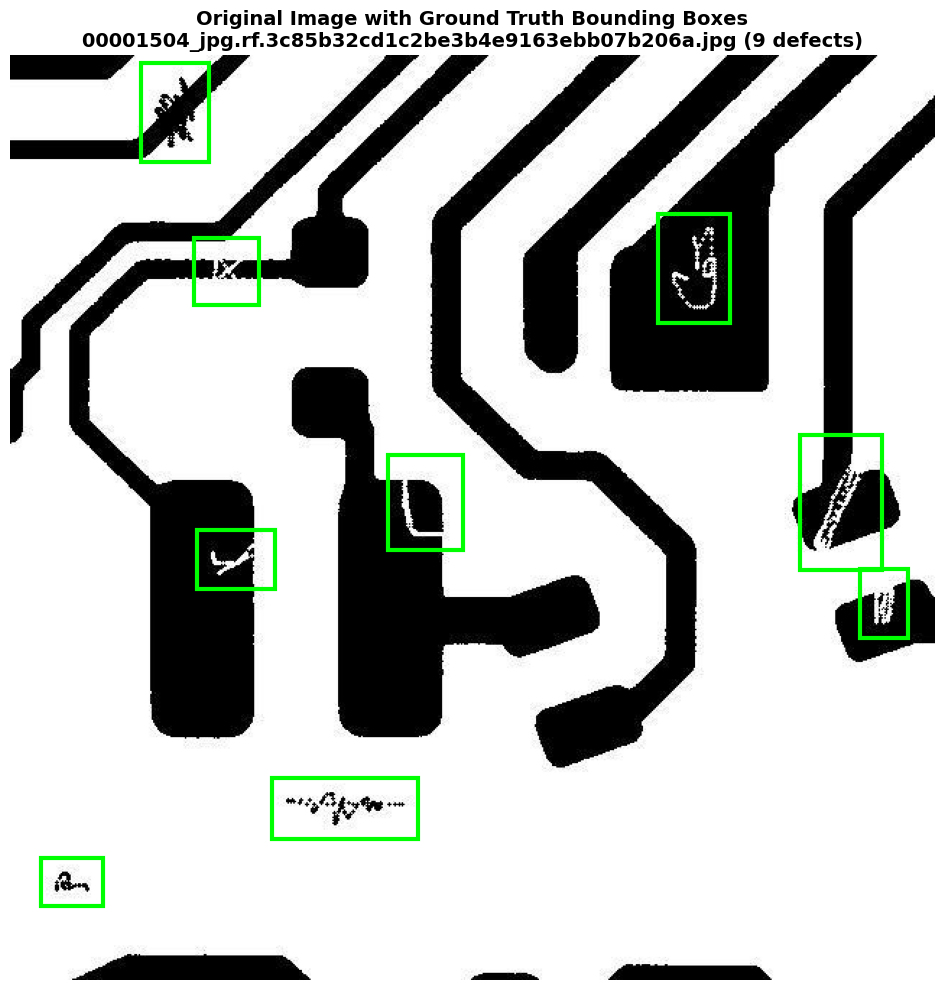

✓ Original image displayed with ground truth bounding boxes (green)


In [49]:
# Display original image WITH ground truth bounding boxes
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.imshow(original_img_np)
ax.set_title(f"Original Image with Ground Truth Bounding Boxes\n{IMAGE_NAME} ({num_gt} defect{'s' if num_gt != 1 else ''})", 
             fontsize=14, fontweight="bold")
ax.axis("off")

# Draw ground truth boxes in GREEN
for box in gt_boxes:
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=3, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)

plt.tight_layout()
plt.show()

print("✓ Original image displayed with ground truth bounding boxes (green)")

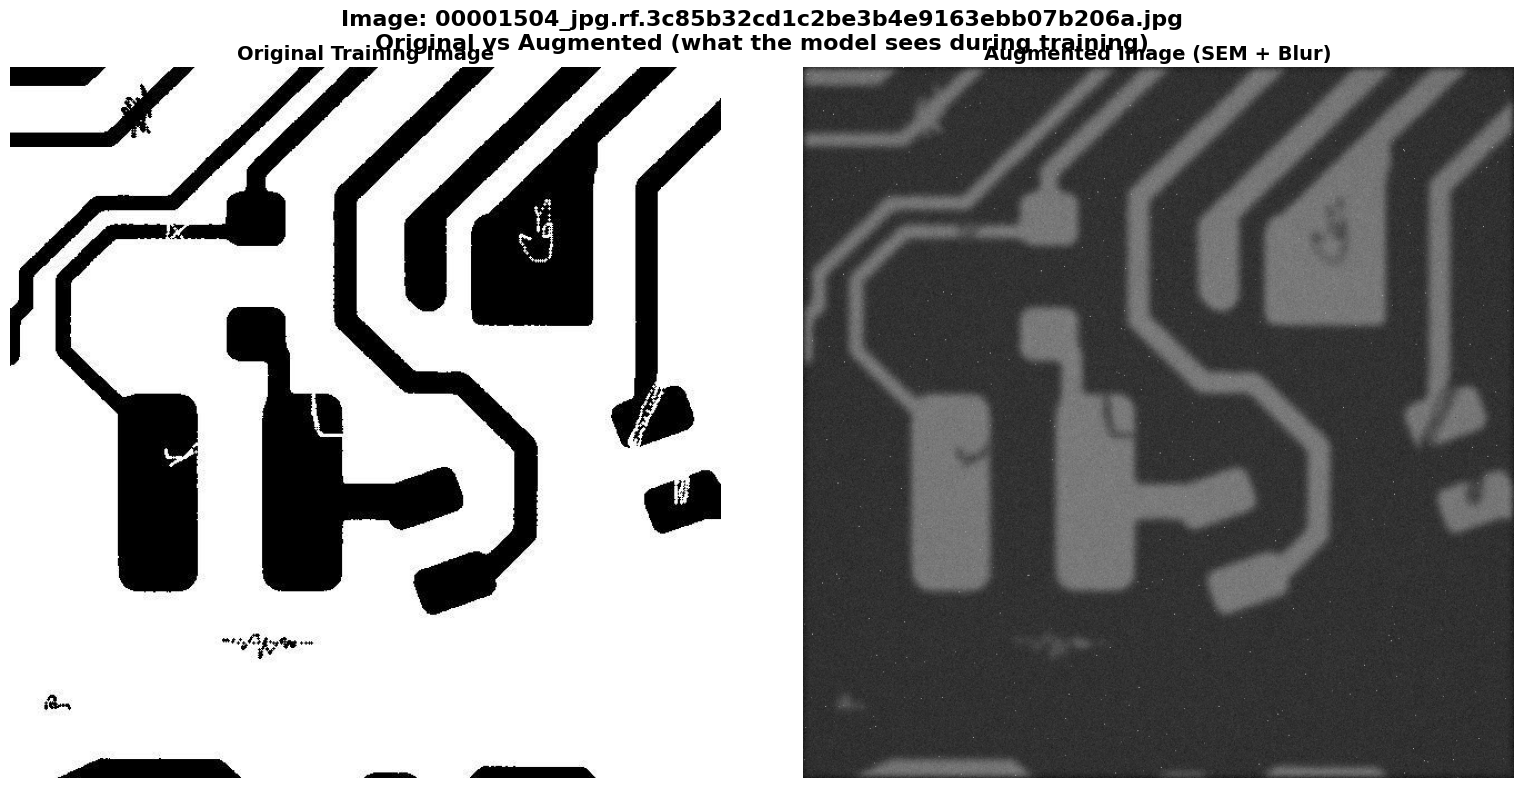


✓ Image comparison displayed!


In [50]:
# Display original and augmented images
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Original image
ax_left = axes[0]
ax_left.imshow(original_img_np)
ax_left.set_title("Original Training Image", fontsize=14, fontweight="bold")
ax_left.axis("off")

# Right: Augmented image
ax_right = axes[1]
ax_right.imshow(augmented_img_np)
ax_right.set_title("Augmented Image (SEM + Blur)", fontsize=14, fontweight="bold")
ax_right.axis("off")

plt.suptitle(f"Image: {IMAGE_NAME}\nOriginal vs Augmented (what the model sees during training)", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✓ Image comparison displayed!")

In [51]:
# Run inference on augmented image
print("Running model inference on augmented image...")

img_tensor = F.to_tensor(augmented_img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    predictions = model(img_tensor)[0]

# Filter predictions by confidence
scores = predictions["scores"].cpu().numpy()
pred_boxes = predictions["boxes"].cpu().numpy()

mask = scores >= CONFIDENCE_THRESHOLD
filtered_boxes = pred_boxes[mask]
filtered_scores = scores[mask]

num_pred = len(filtered_boxes)
print(f"✓ Inference complete!")
print(f"  Predicted: {num_pred} defect(s) with confidence ≥ {CONFIDENCE_THRESHOLD}")
print(f"  Ground truth: {num_gt} defect(s)")

Running model inference on augmented image...
✓ Inference complete!
  Predicted: 10 defect(s) with confidence ≥ 0.5
  Ground truth: 9 defect(s)


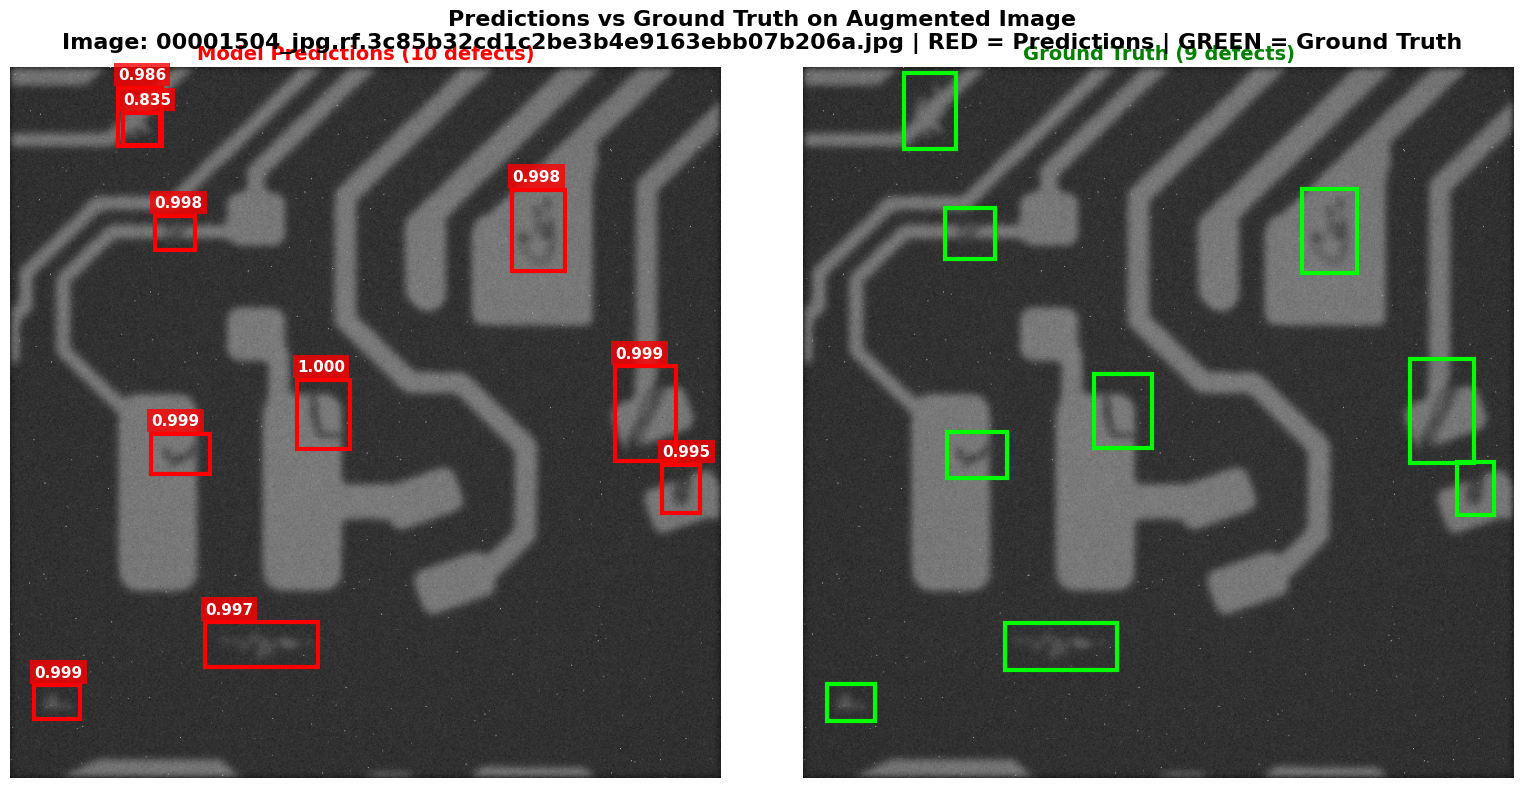


✓ Predictions vs ground truth visualization complete!


In [52]:
# Display predictions vs ground truth on augmented image
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Augmented image with model predictions (RED)
ax_left = axes[0]
ax_left.imshow(augmented_img_np)
ax_left.set_title(f"Model Predictions ({num_pred} defect{'s' if num_pred != 1 else ''})", 
                  fontsize=14, fontweight="bold", color="red")
ax_left.axis("off")

for box, score in zip(filtered_boxes, filtered_scores):
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=3, edgecolor="red", facecolor="none")
    ax_left.add_patch(rect)
    
    # Add confidence score
    ax_left.text(x1, y1 - 8, f"{score:.3f}", 
                bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=3),
                fontsize=11, color="white", fontweight="bold")

# Right: Augmented image with ground truth (GREEN)
ax_right = axes[1]
ax_right.imshow(augmented_img_np)
ax_right.set_title(f"Ground Truth ({num_gt} defect{'s' if num_gt != 1 else ''})", 
                   fontsize=14, fontweight="bold", color="green")
ax_right.axis("off")

for box in gt_boxes:
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=3, edgecolor="lime", facecolor="none")
    ax_right.add_patch(rect)

plt.suptitle(f"Predictions vs Ground Truth on Augmented Image\n" +
             f"Image: {IMAGE_NAME} | RED = Predictions | GREEN = Ground Truth",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✓ Predictions vs ground truth visualization complete!")

In [53]:
# Print detailed detection results and comparison
print("\n" + "="*80)
print("DETECTION SUMMARY")
print("="*80)
print(f"Image: {IMAGE_NAME}")
print(f"Ground Truth Defects: {num_gt}")
print(f"Predicted Defects: {num_pred} (confidence ≥ {CONFIDENCE_THRESHOLD})")
print(f"Difference: {abs(num_pred - num_gt)} {'(Over-detection)' if num_pred > num_gt else '(Under-detection)' if num_pred < num_gt else '(Perfect count!)'}")
print("="*80)

if num_pred > 0:
    print("\nPREDICTIONS:")
    print(f"{'#':<4} {'Confidence':<12} {'Bounding Box (x1, y1, x2, y2)':<40}")
    print("-"*80)
    for i, (box, score) in enumerate(zip(filtered_boxes, filtered_scores), 1):
        x1, y1, x2, y2 = box
        bbox_str = f"({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
        print(f"{i:<4} {score:.4f}      {bbox_str}")

if num_gt > 0:
    print("\nGROUND TRUTH:")
    print(f"{'#':<4} {'Bounding Box (x1, y1, x2, y2)':<40}")
    print("-"*80)
    for i, box in enumerate(gt_boxes, 1):
        x1, y1, x2, y2 = box
        bbox_str = f"({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
        print(f"{i:<4} {bbox_str}")

print("="*80)


DETECTION SUMMARY
Image: 00001504_jpg.rf.3c85b32cd1c2be3b4e9163ebb07b206a.jpg
Ground Truth Defects: 9
Predicted Defects: 10 (confidence ≥ 0.5)
Difference: 1 (Over-detection)

PREDICTIONS:
#    Confidence   Bounding Box (x1, y1, x2, y2)           
--------------------------------------------------------------------------------
1    0.9997      (258.1, 281.3, 306.1, 343.7)
2    0.9995      (126.8, 329.5, 179.3, 366.1)
3    0.9991      (544.7, 269.0, 599.2, 354.4)
4    0.9990      (21.4, 556.2, 62.5, 586.1)
5    0.9984      (129.7, 133.2, 166.2, 164.0)
6    0.9977      (451.9, 109.6, 499.4, 182.7)
7    0.9967      (175.1, 499.5, 277.1, 539.3)
8    0.9952      (586.9, 357.4, 620.7, 401.0)
9    0.9859      (96.8, 18.2, 136.2, 70.1)
10   0.8353      (101.2, 40.4, 135.0, 69.8)

GROUND TRUTH:
#    Bounding Box (x1, y1, x2, y2)           
--------------------------------------------------------------------------------
1    (127.0, 126.0, 172.0, 172.0)
2    (261.0, 276.0, 313.0, 342.0)
3    (54

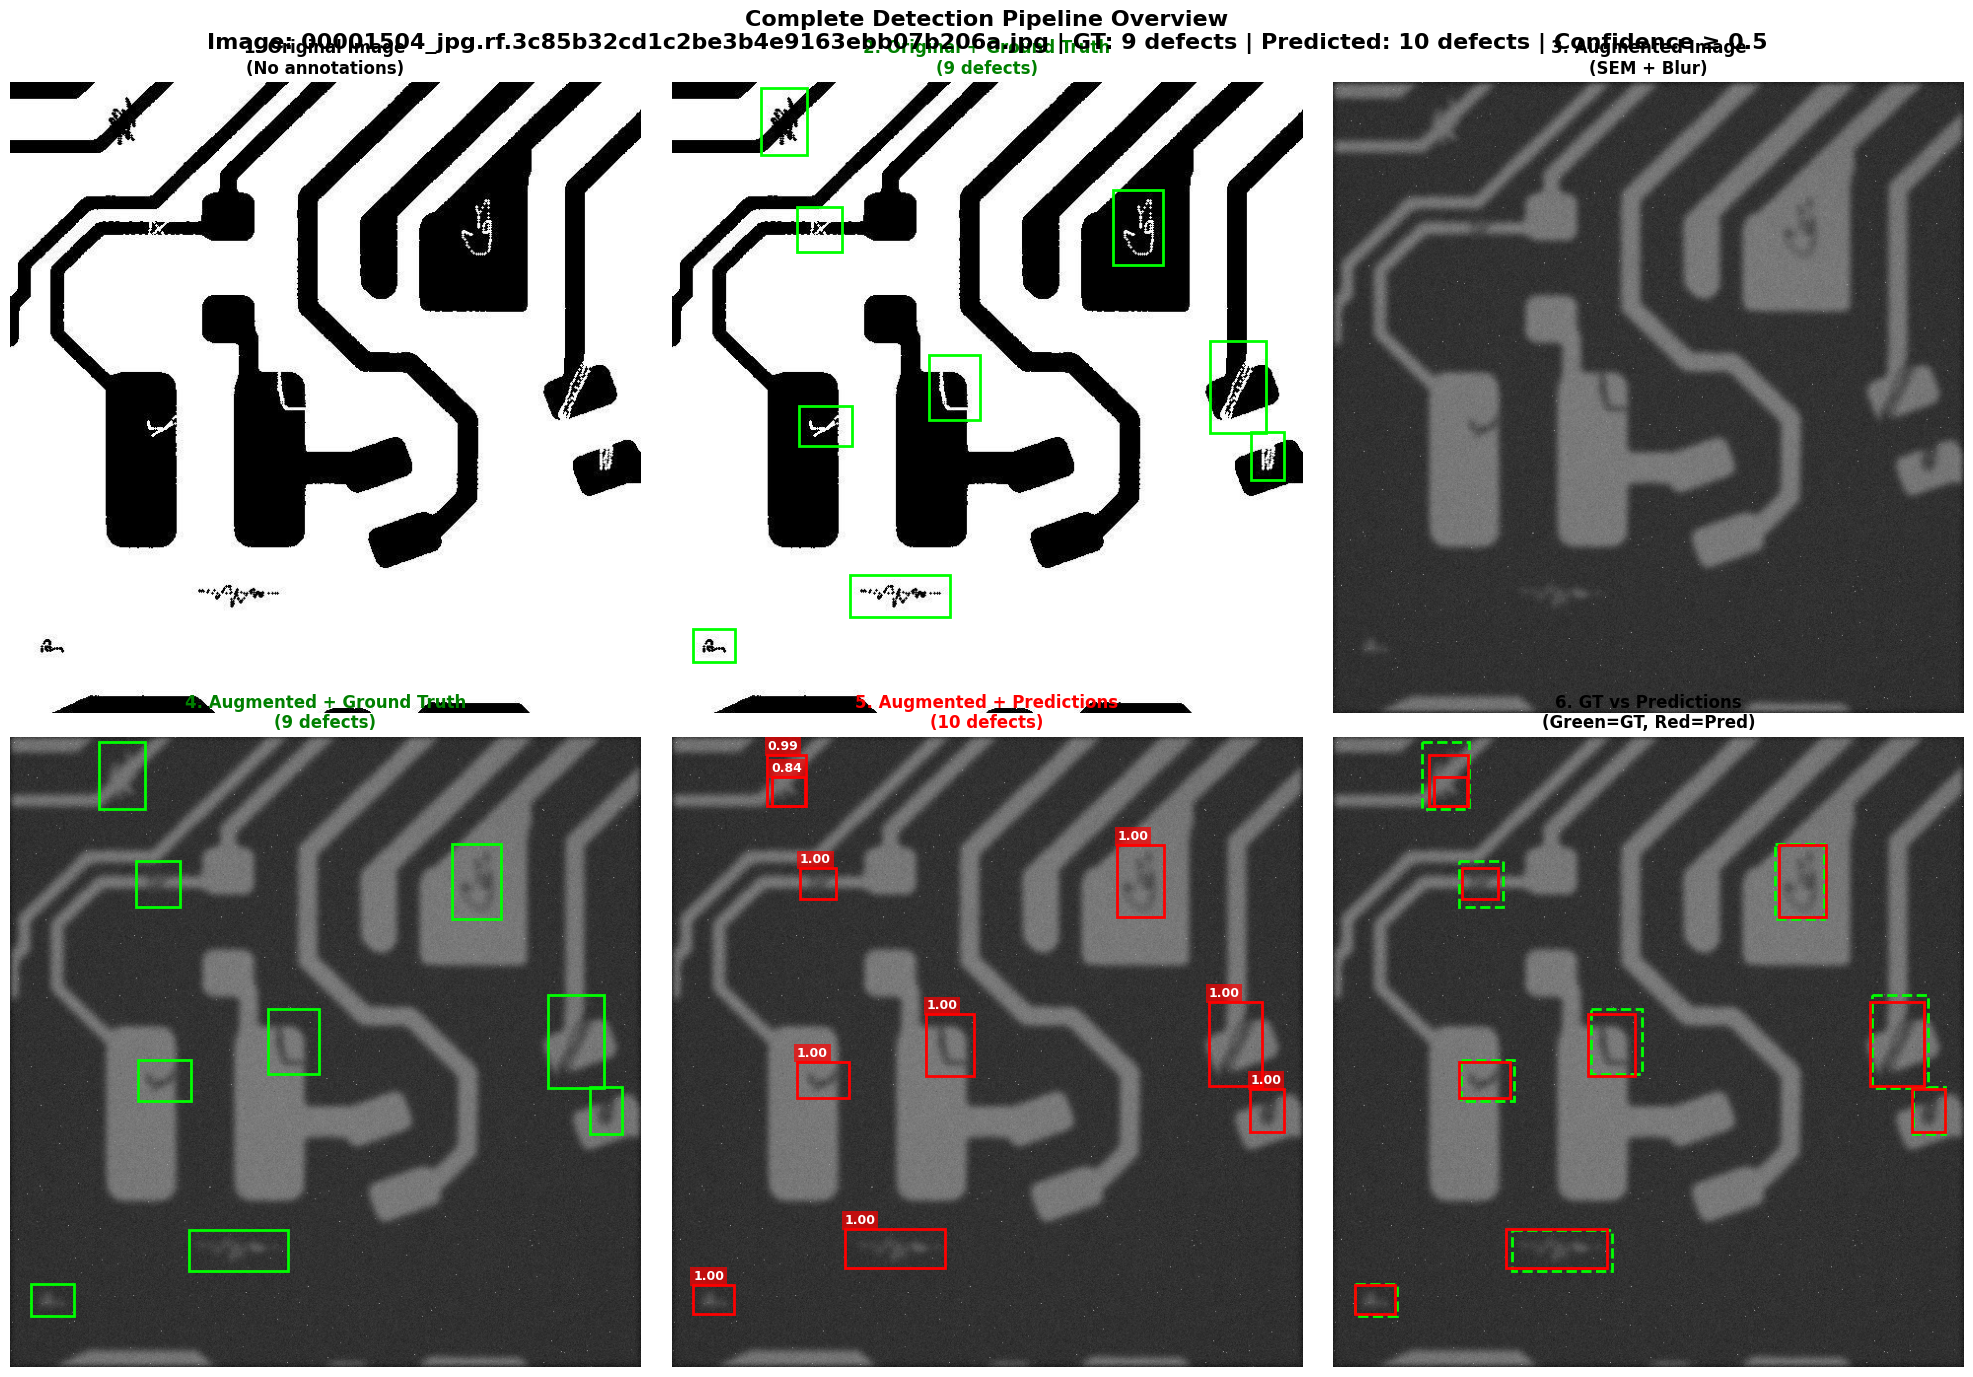


✓ Complete pipeline overview displayed!


In [54]:
# Display all images side by side - Complete Pipeline Overview
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# Row 1: Original images
# Column 1: Original image (clean)
ax1 = axes[0, 0]
ax1.imshow(original_img_np)
ax1.set_title("1. Original Image\n(No annotations)", fontsize=12, fontweight="bold")
ax1.axis("off")

# Column 2: Original with GT boxes
ax2 = axes[0, 1]
ax2.imshow(original_img_np)
ax2.set_title(f"2. Original + Ground Truth\n({num_gt} defect{'s' if num_gt != 1 else ''})", 
              fontsize=12, fontweight="bold", color="green")
ax2.axis("off")
for box in gt_boxes:
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="lime", facecolor="none")
    ax2.add_patch(rect)

# Column 3: Augmented image
ax3 = axes[0, 2]
ax3.imshow(augmented_img_np)
ax3.set_title("3. Augmented Image\n(SEM + Blur)", fontsize=12, fontweight="bold")
ax3.axis("off")

# Row 2: Analysis images
# Column 1: Augmented with GT
ax4 = axes[1, 0]
ax4.imshow(augmented_img_np)
ax4.set_title(f"4. Augmented + Ground Truth\n({num_gt} defect{'s' if num_gt != 1 else ''})", 
              fontsize=12, fontweight="bold", color="green")
ax4.axis("off")
for box in gt_boxes:
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="lime", facecolor="none")
    ax4.add_patch(rect)

# Column 2: Augmented with Predictions
ax5 = axes[1, 1]
ax5.imshow(augmented_img_np)
ax5.set_title(f"5. Augmented + Predictions\n({num_pred} defect{'s' if num_pred != 1 else ''})", 
              fontsize=12, fontweight="bold", color="red")
ax5.axis("off")
for box, score in zip(filtered_boxes, filtered_scores):
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="red", facecolor="none")
    ax5.add_patch(rect)
    ax5.text(x1, y1 - 5, f"{score:.2f}", 
            bbox=dict(facecolor="red", alpha=0.7, edgecolor="none", pad=2),
            fontsize=9, color="white", fontweight="bold")

# Column 3: Comparison (both GT and Pred)
ax6 = axes[1, 2]
ax6.imshow(augmented_img_np)
ax6.set_title("6. GT vs Predictions\n(Green=GT, Red=Pred)", fontsize=12, fontweight="bold")
ax6.axis("off")
# Draw GT in green
for box in gt_boxes:
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="lime", facecolor="none", linestyle="--")
    ax6.add_patch(rect)
# Draw predictions in red
for box, score in zip(filtered_boxes, filtered_scores):
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="red", facecolor="none")
    ax6.add_patch(rect)

plt.suptitle(f"Complete Detection Pipeline Overview\n" +
             f"Image: {IMAGE_NAME} | GT: {num_gt} defects | Predicted: {num_pred} defects | Confidence ≥ {CONFIDENCE_THRESHOLD}",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✓ Complete pipeline overview displayed!")